In [1]:
import torch
from torchlight import import_class
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics.pairwise import cosine_distances
from sklearn.decomposition import PCA
import os
import sys

sys.path.append(os.path.abspath('../utils'))
from analysis_utils import load_or_compute_embeddings

# NTU Analysis

In [3]:
sys.path.append(os.path.abspath('../models/CrosSCLR'))
Model = import_class('net.crossclr_3views.CrosSCLR')
model_args = {
    'base_encoder': 'net.st_gcn.Model',
    'pretrain': True,
    'feature_dim': 128,
    'queue_size': 32768,
    'momentum': 0.999,
    'Temperature': 0.07,
    'mlp': True,
    'in_channels': 3,
    'hidden_channels': 16,
    'hidden_dim': 256,
    'num_class': 60,
    'dropout': 0.5,
    'graph_args': {'layout': 'ntu-rgb+d', 'strategy': 'spatial'},
    'edge_importance_weighting': True,
}
model = Model(**model_args)

ntu_state_dict = torch.load('../models/CrosSCLR/work_dir/crossclr_3views/finetune_goalkeeper_v2/epoch100_model.pt')

# remove queue buffers
for k in list(ntu_state_dict.keys()):
    if k.startswith('queue'):
        del ntu_state_dict[k]

model.load_state_dict(ntu_state_dict, strict=False)
model.eval()

model_name = "finetuned"

In [ ]:
N = 2000
all_views, labels_snfc = load_or_compute_embeddings(model, dataset_name='snfc', N=N, model_name=model_name)

Loading joint embeddings from ../models/CrosSCLR/embeddings/snfc_finetuned_embeddings_val_joint_2000.pt
Loading motion embeddings from ../models/CrosSCLR/embeddings/snfc_finetuned_embeddings_val_motion_2000.pt
Loading bone embeddings from ../models/CrosSCLR/embeddings/snfc_finetuned_embeddings_val_bone_2000.pt
Loading all embeddings from ../models/CrosSCLR/embeddings/snfc_finetuned_embeddings_val_all_2000.pt
All data loaded successfully.


In [5]:
for view, embeddings in all_views.items():
    print(f"----------Statistics for view {view}----------")
    centroid = embeddings.mean()
    print(centroid.norm())
    print(embeddings.norm(dim=1, keepdim=True).mean())

----------Statistics for view joint----------
tensor(0.0004)
tensor(1.)
----------Statistics for view motion----------
tensor(0.0006)
tensor(1.)
----------Statistics for view bone----------
tensor(0.0021)
tensor(1.)
----------Statistics for view all----------
tensor(0.0002)
tensor(1.)


torch.Size([100, 100])
Min similarity: -0.3538
Max similarity: 1.0000


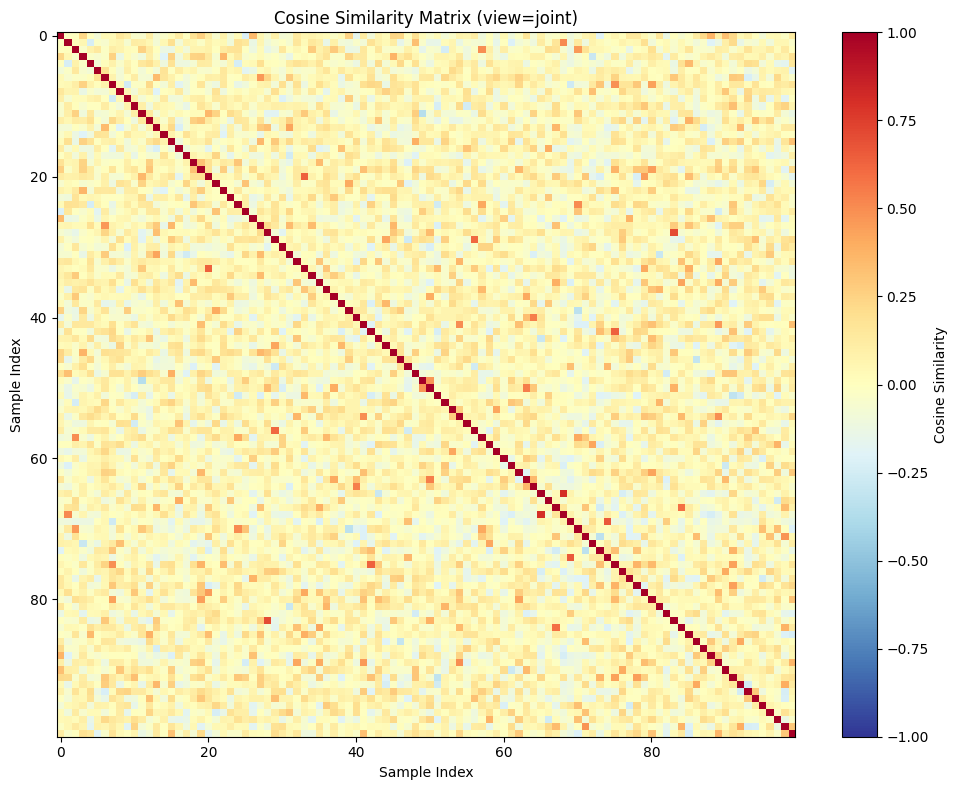

torch.Size([100, 100])
Min similarity: -0.3347
Max similarity: 1.0000


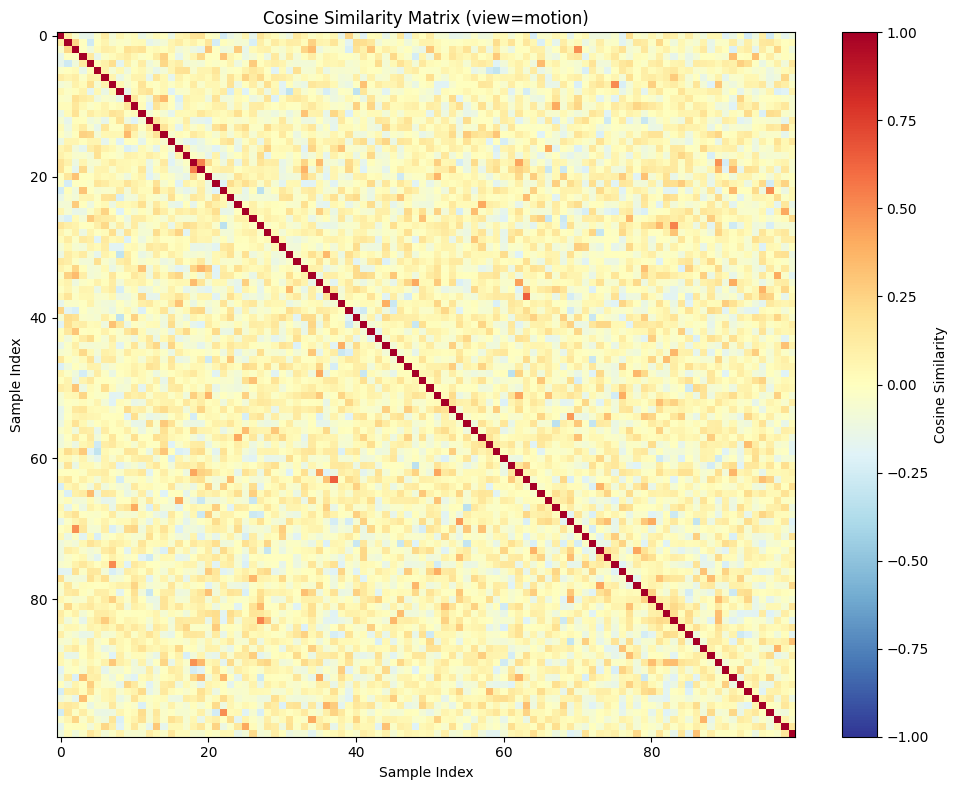

torch.Size([100, 100])
Min similarity: -0.3383
Max similarity: 1.0000


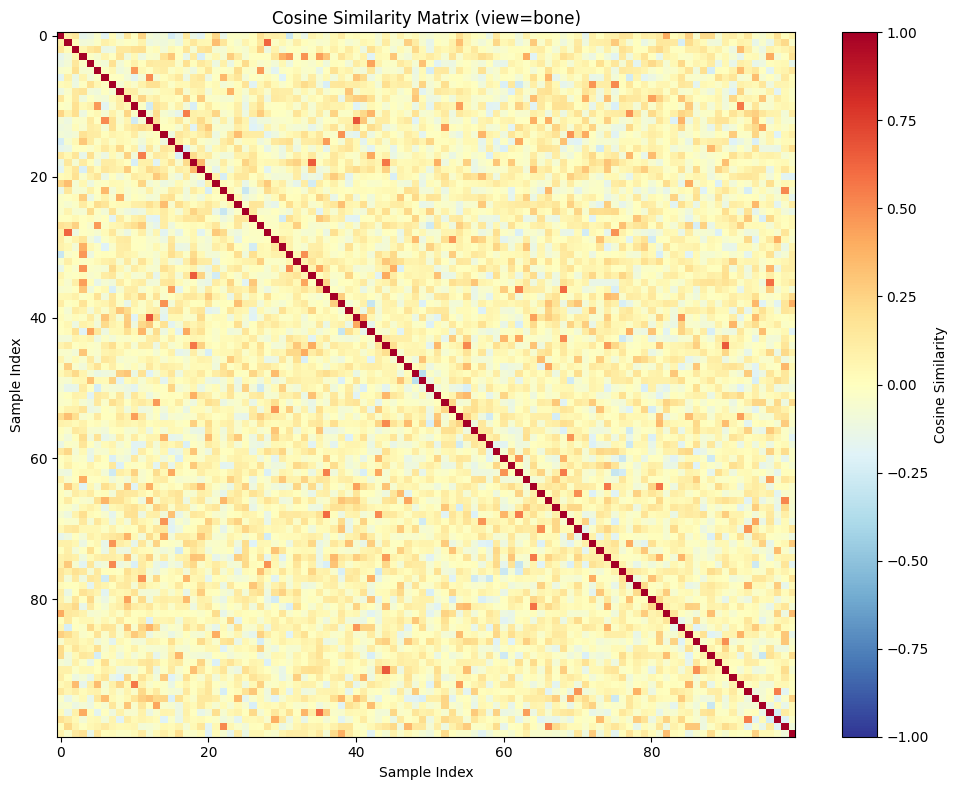

torch.Size([100, 100])
Min similarity: -0.4264
Max similarity: 1.0000


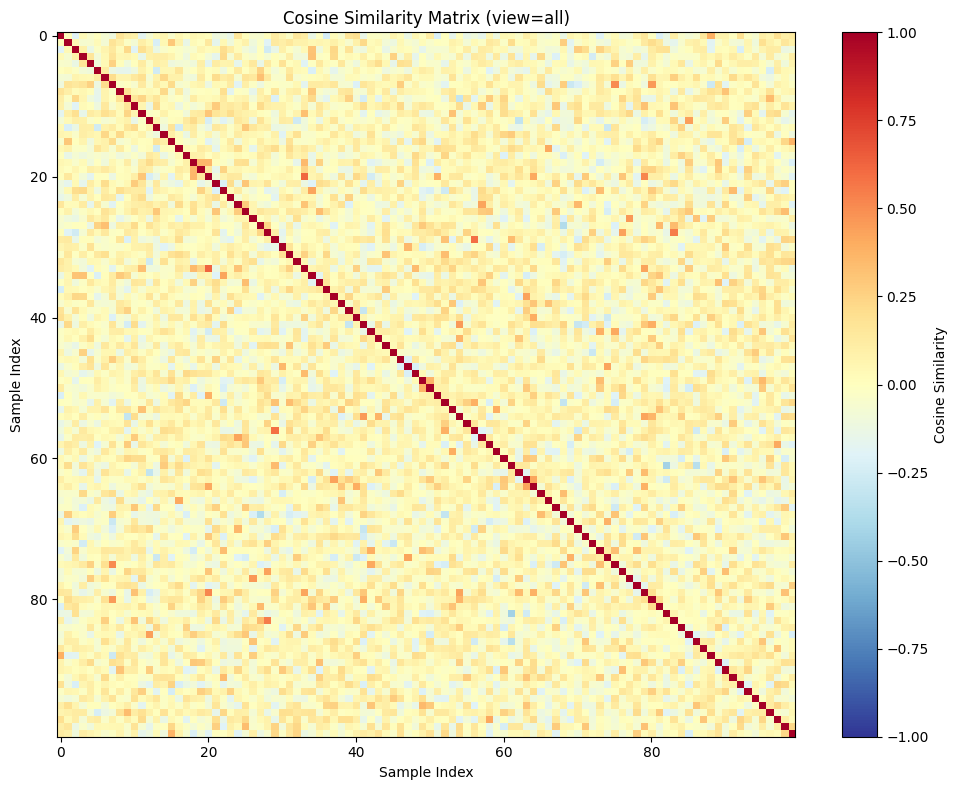

In [6]:
# Compute cosine similarity matrix for randomly sampled embeddings
from torch.nn.functional import cosine_similarity
num_samples = next(iter(all_views.values())).shape[0]
if num_samples >= 10:
    random_indices = torch.randperm(num_samples)[:100]
else:
    random_indices = torch.randperm(num_samples)

for view, embeddings in all_views.items():
    embeddings = embeddings[random_indices]
    # Normalize embeddings (if not already normalized)
    embeddings_norm = embeddings / embeddings.norm(dim=1, keepdim=True)
    # Compute cosine similarity matrix: (N, N)
    similarity_matrix = embeddings_norm @ embeddings_norm.T
    print(similarity_matrix.shape)
    print(f"Min similarity: {similarity_matrix.min():.4f}")
    print(f"Max similarity: {similarity_matrix.max():.4f}")
    plt.figure(figsize=(10, 8))
    plt.imshow(similarity_matrix.cpu().numpy(), cmap='RdYlBu_r', aspect='auto', vmin=-1, vmax=1)
    plt.colorbar(label='Cosine Similarity')
    plt.title(f'Cosine Similarity Matrix (view={view})')
    plt.xlabel('Sample Index')
    plt.ylabel('Sample Index')
    plt.tight_layout()
    plt.show()

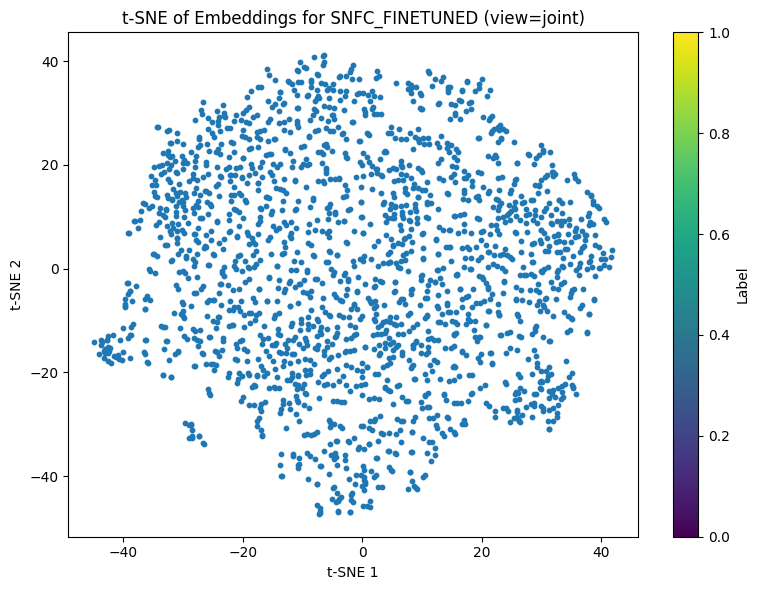

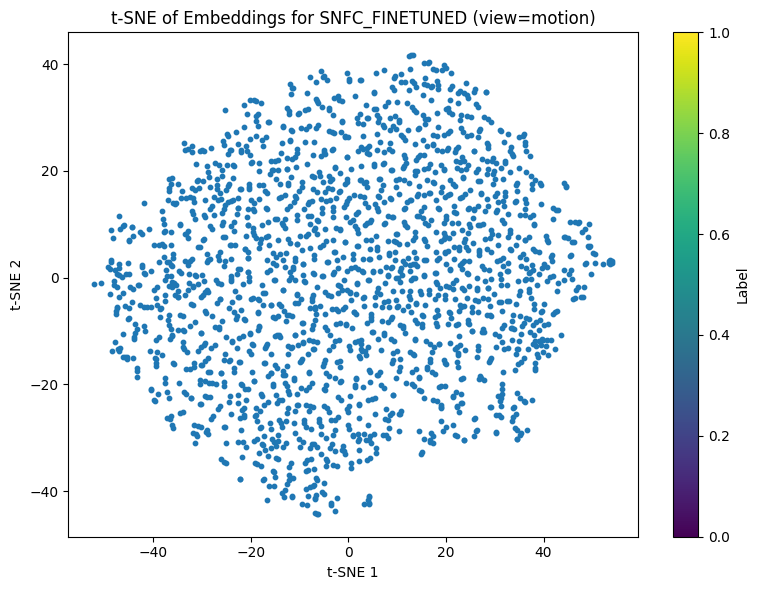

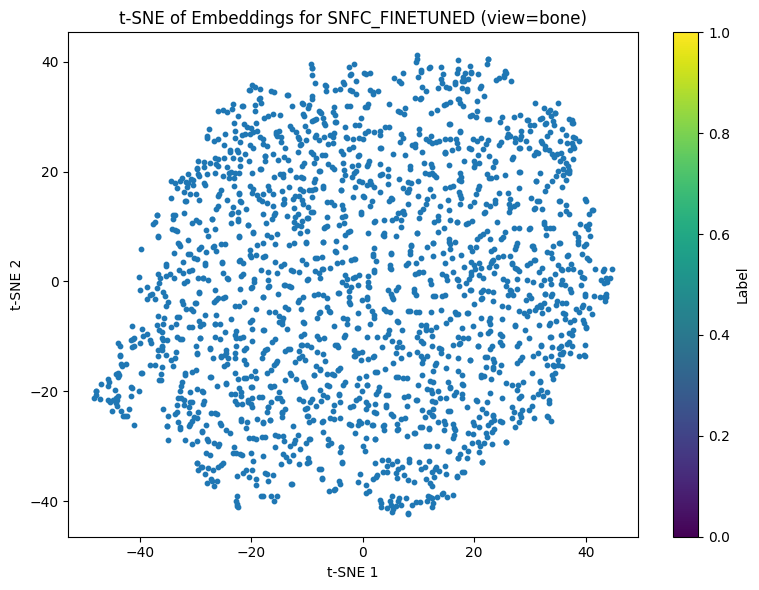

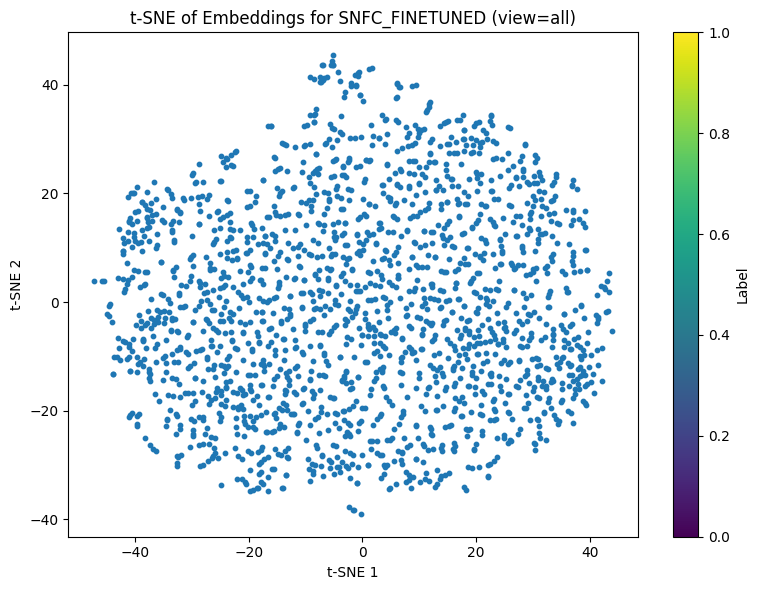

In [24]:
# Convert to numpy if needed

for view, embeddings in all_views.items():
    if isinstance(embeddings, torch.Tensor):
        emb_np = embeddings.cpu().numpy()
    else:
        emb_np = embeddings

    # Run t-SNE
    tsne = TSNE(n_components=2, perplexity=50, random_state=42)
    emb_2d = tsne.fit_transform(emb_np)

    # Plot with color by label
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(emb_2d[:, 0], emb_2d[:, 1], s=10)
    plt.title(f"t-SNE of Embeddings for SNFC_FINETUNED (view={view})")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.tight_layout()
    plt.show()

# Working with NTU Datasets but with finetuned model

In [16]:
N = 2000
ntu_views, labels_ntu = load_or_compute_embeddings(model, dataset_name='ntu', N=N, model_name=model_name)

Loading joint embeddings from ../models/CrosSCLR/embeddings/ntu_finetuned_embeddings_val_joint_2000.pt
Loading motion embeddings from ../models/CrosSCLR/embeddings/ntu_finetuned_embeddings_val_motion_2000.pt
Loading bone embeddings from ../models/CrosSCLR/embeddings/ntu_finetuned_embeddings_val_bone_2000.pt
Loading all embeddings from ../models/CrosSCLR/embeddings/ntu_finetuned_embeddings_val_all_2000.pt
Loading labels from ../models/CrosSCLR/embeddings/ntu_finetuned_embeddings_val_labels_2000.pt
All data loaded successfully.


torch.Size([100, 100])
Min similarity: -0.3260
Max similarity: 1.0000


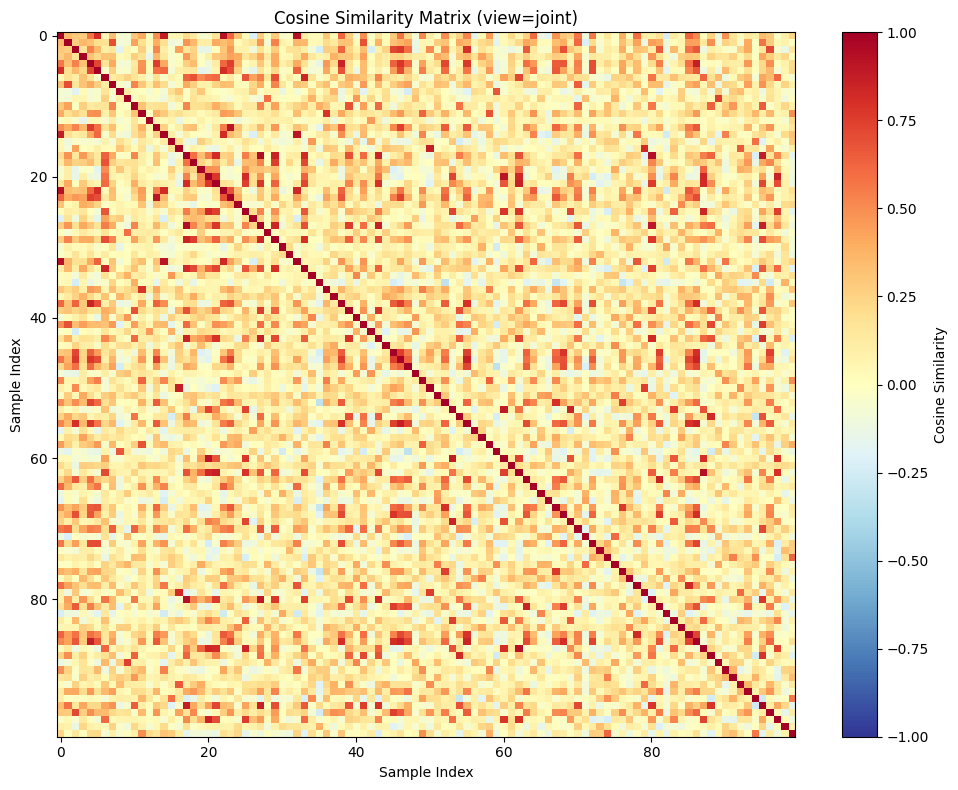

torch.Size([100, 100])
Min similarity: -0.2683
Max similarity: 1.0000


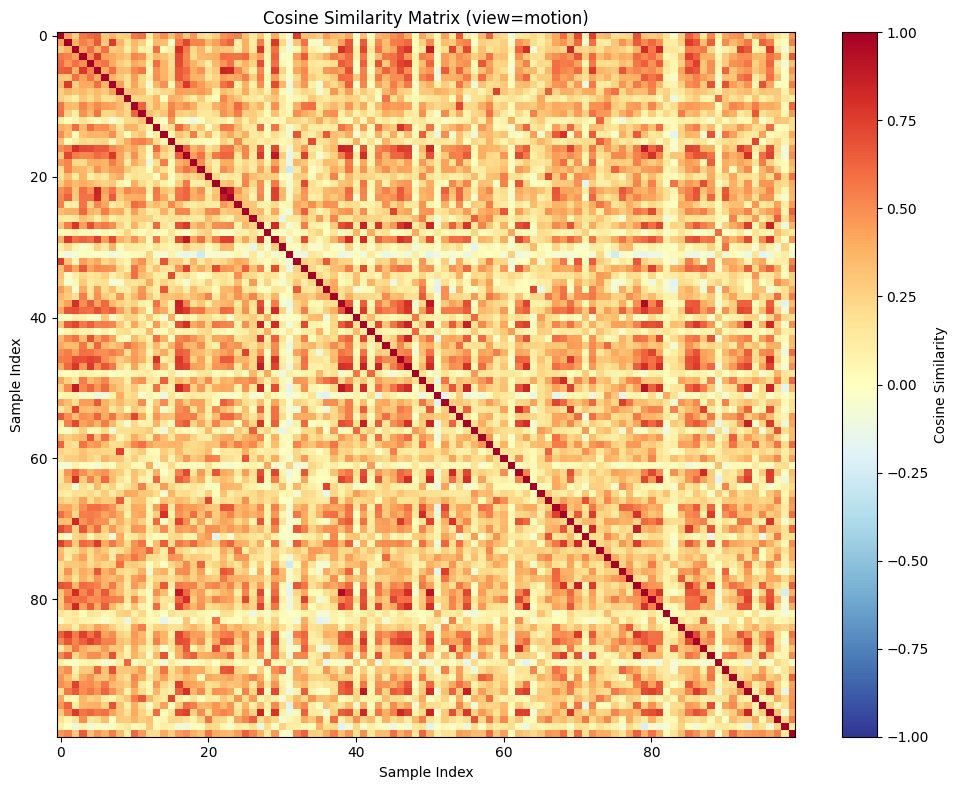

torch.Size([100, 100])
Min similarity: -0.3672
Max similarity: 1.0000


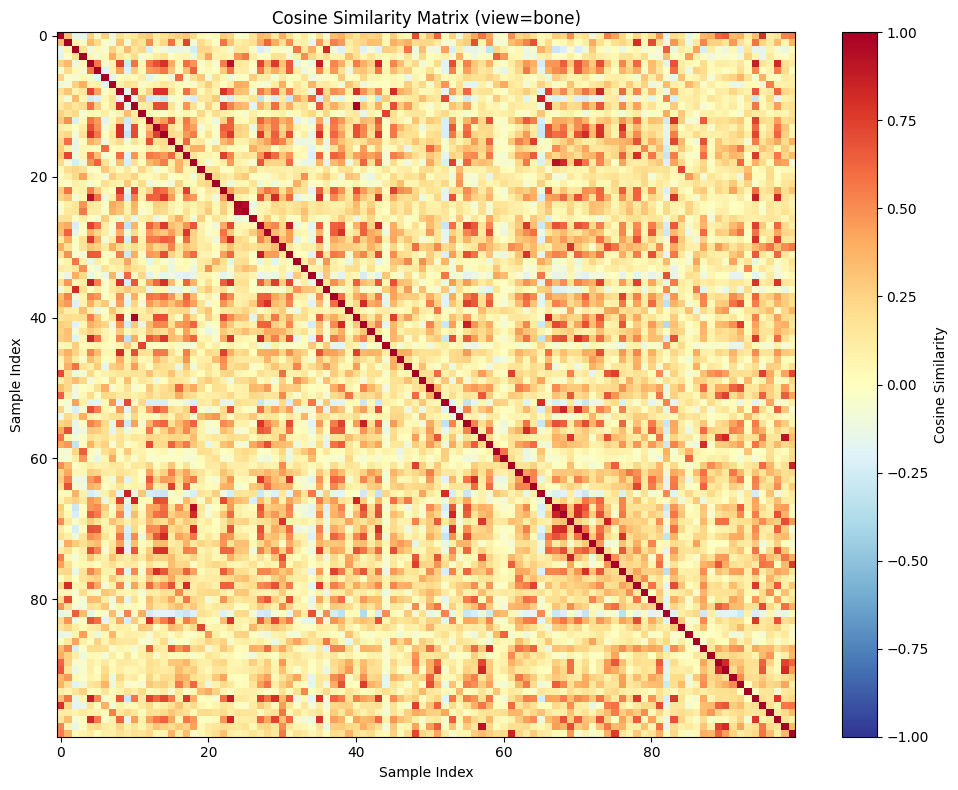

torch.Size([100, 100])
Min similarity: -0.2620
Max similarity: 1.0000


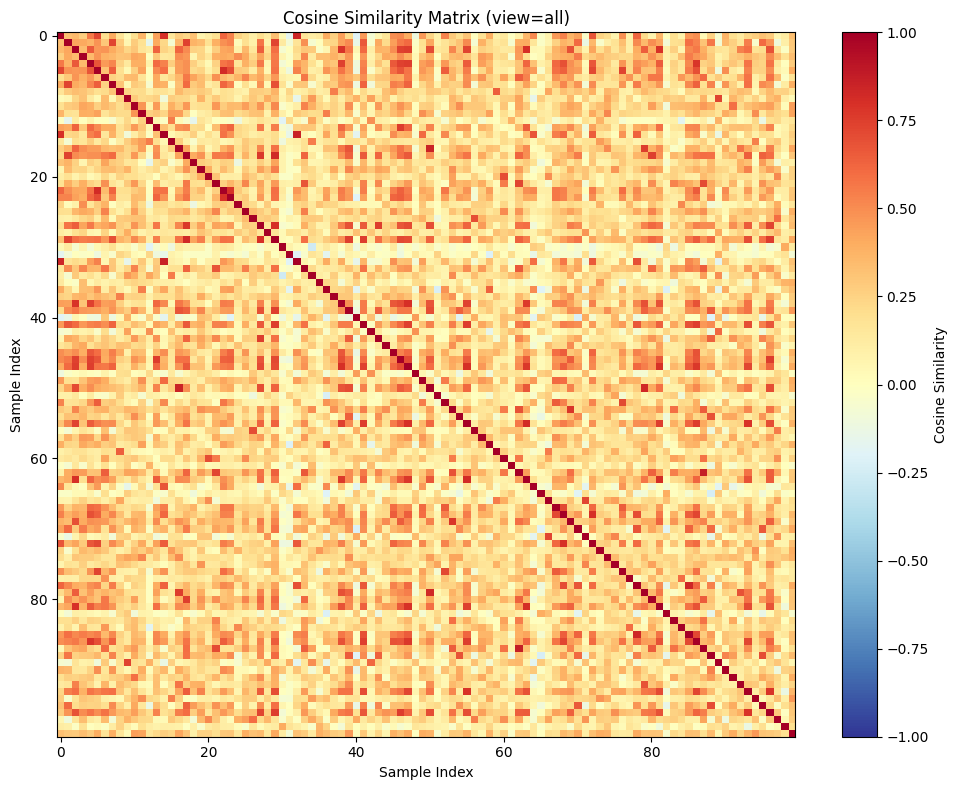

In [ ]:

# Get 10 random indices from the full range of labels
class_indices = (labels_ntu == 50).nonzero(as_tuple=True)[0]
num_samples = len(labels_ntu)
if num_samples >= 10:
    random_indices = torch.randperm(num_samples)[:50]
else:
    random_indices = torch.randperm(num_samples)

num_samples = next(iter(all_views.values())).shape[0]
if num_samples >= 10:
    random_indices = torch.randperm(num_samples)[:100]
else:
    random_indices = torch.randperm(num_samples)

for view, embeddings in ntu_views.items():
    embeddings = embeddings[random_indices]
    # Normalize embeddings (if not already normalized)
    embeddings_norm = embeddings / embeddings.norm(dim=1, keepdim=True)
    # Compute cosine similarity matrix: (N, N)
    similarity_matrix = embeddings_norm @ embeddings_norm.T
    print(similarity_matrix.shape)
    print(f"Min similarity: {similarity_matrix.min():.4f}")
    print(f"Max similarity: {similarity_matrix.max():.4f}")
    plt.figure(figsize=(10, 8))
    plt.imshow(similarity_matrix.cpu().numpy(), cmap='RdYlBu_r', aspect='auto', vmin=-1, vmax=1)
    plt.colorbar(label='Cosine Similarity')
    plt.title(f'Cosine Similarity Matrix (view={view})')
    plt.xlabel('Sample Index')
    plt.ylabel('Sample Index')
    plt.tight_layout()
    plt.show()

(2000,)
Analysing 366 points!


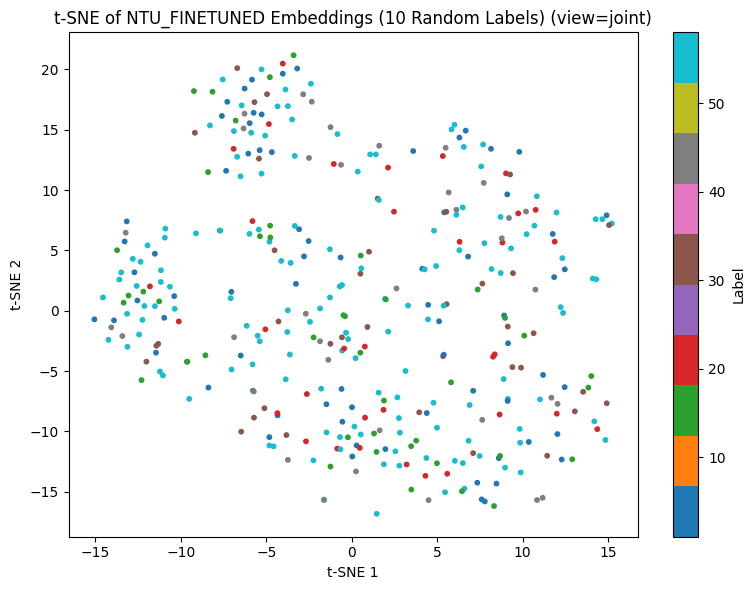

Analysing 366 points!


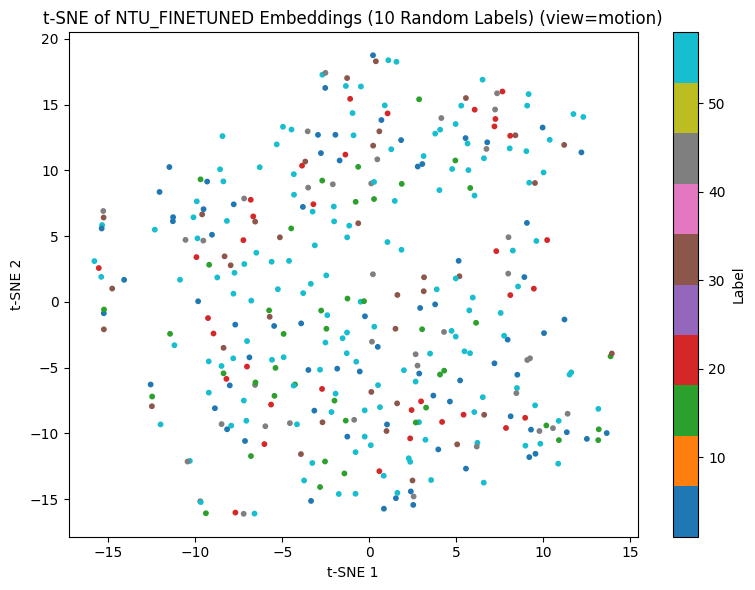

Analysing 366 points!


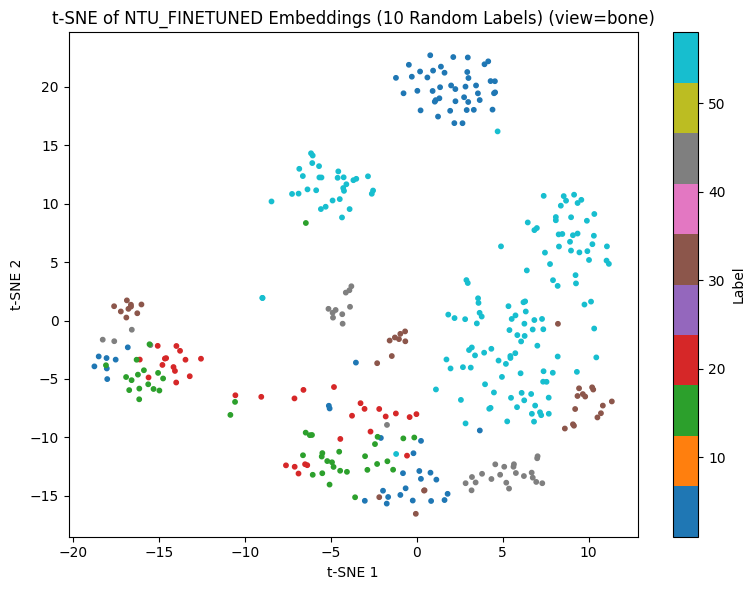

Analysing 366 points!


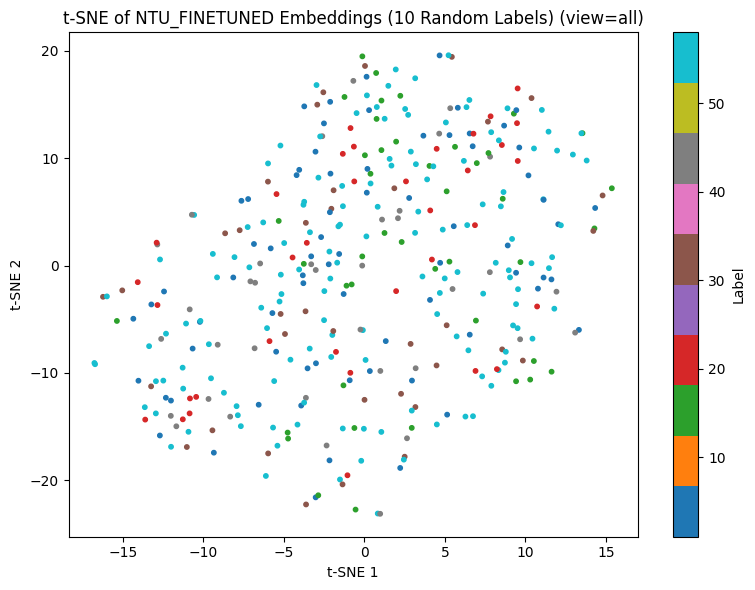

In [26]:

# Sample 10 unique labels
num_labels_to_analyse = 10
if isinstance(labels_ntu, torch.Tensor):
    labels_np = labels_ntu.cpu().numpy()
else:
    labels_np = labels_ntu
unique_labels = np.unique(labels_np)
sampled_labels = np.random.choice(unique_labels, num_labels_to_analyse, replace=False)

# Mask for embeddings with those labels
mask = np.isin(labels_np, sampled_labels).reshape(-1)
print(mask.shape)

for view, embeddings in ntu_views.items():
    if isinstance(embeddings, torch.Tensor):
        emb_np = embeddings.cpu().numpy()
    else:
        emb_np = embeddings
    
    emb_np_sub = emb_np[mask]
    print(f"Analysing {emb_np_sub.shape[0]} points!")
    labels_np_sub = labels_np[mask]

    # Run t-SNE
    tsne = TSNE(n_components=2, perplexity=40, random_state=42)
    emb_2d = tsne.fit_transform(emb_np_sub)

    # Plot with color by label
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=labels_np_sub, cmap='tab10', s=10)
    plt.colorbar(scatter, label='Label')
    plt.title(f"t-SNE of NTU_FINETUNED Embeddings ({num_labels_to_analyse} Random Labels) (view={view})")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.tight_layout()
    plt.show()